# 06 — Veri Dengeleme Analizi
Mevcut labels.csv'deki tur dengesizligini olc. Phase 7 hedefli scraping icin `gap_report.csv` uret.

In [1]:
import ast
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Yerel ---
CODE_ROOT = Path('../')
DATA_ROOT = Path('../')

# --- Colab ---
# from google.colab import drive
# drive.mount('/content/drive')
# CODE_ROOT = Path('/content/drive/MyDrive/film-genre-project')
# DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')

LABELS_CSV  = DATA_ROOT / 'labels.csv'
POSTERS_DIR = DATA_ROOT / 'posters'
GAP_REPORT  = DATA_ROOT / 'gap_report.csv'

TARGET_PER_GENRE = 2000
TARGET_PER_COMBO = 50
DOWNSAMPLE_TO    = 2500  # Drama ve Comedy icin

TARGET_GENRES = [
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
    'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller'
]

print('Paths OK:', LABELS_CSV.exists(), POSTERS_DIR.exists())

Paths OK: True True


## 1. Veri Yukleme

In [2]:
df = pd.read_csv(LABELS_CSV, dtype={'tmdb_id': str})

# Pipeline '|' ile kaydediyor: 'Action|Drama|Thriller'
df['genres'] = df['genres'].apply(lambda x: x.split('|') if isinstance(x, str) else [])

# Sadece TARGET_GENRES icindeki turleri tut
df['genres'] = df['genres'].apply(
    lambda gs: [g for g in gs if g in TARGET_GENRES]
)
df = df[df['genres'].map(len) > 0].reset_index(drop=True)

# Poster dosyasi kontrolu
df['poster_exists'] = df['tmdb_id'].apply(
    lambda tid: (POSTERS_DIR / f'{tid}.jpg').exists()
)
missing_posters = (~df['poster_exists']).sum()
df = df[df['poster_exists']].reset_index(drop=True)

print(f'Toplam film       : {len(df):,}')
print(f'Postersiz dusulen : {missing_posters}')
print(f'Ort. tur/film     : {df["genres"].map(len).mean():.2f}')
print(f'Max tur/film      : {df["genres"].map(len).max()}')
df.head(3)

Toplam film       : 12,090
Postersiz dusulen : 28
Ort. tur/film     : 2.27
Max tur/film      : 7


,tmdb_id,title,genres,poster_exists
0,1241752,Rita,[Drama],True
1,1171145,Crime 101,"[Crime, Thriller]",True
2,502356,The Super Mario Bros. Movie,"[Family, Comedy, Adventure, Fantasy, Animation]",True


## 2. Per-genre Sayimi ve Acik Analizi

In [3]:
genre_counts = Counter(g for gs in df['genres'] for g in gs)

counts_df = pd.DataFrame(
    [(g, genre_counts.get(g, 0)) for g in TARGET_GENRES],
    columns=['genre', 'count']
).sort_values('count', ascending=True).reset_index(drop=True)

counts_df['target'] = counts_df['genre'].apply(
    lambda g: DOWNSAMPLE_TO if g in ('Drama', 'Comedy') else TARGET_PER_GENRE
)
counts_df['deficit'] = (counts_df['target'] - counts_df['count']).clip(lower=0)
counts_df['surplus'] = (counts_df['count'] - counts_df['target']).clip(lower=0)
counts_df['status'] = counts_df['deficit'].apply(lambda d: 'EKSIK' if d > 0 else 'TAMAM')

print(counts_df.to_string(index=False))
print(f'\nToplam scraping ihtiyaci (alt sinir): ~{counts_df["deficit"].sum():,} film')

          genre  count  target  deficit  surplus status
        History    532    2000     1468        0  EKSIK
    Documentary    593    2000     1407        0  EKSIK
      Animation    656    2000     1344        0  EKSIK
        Mystery    830    2000     1170        0  EKSIK
        Fantasy    960    2000     1040        0  EKSIK
         Family   1057    2000      943        0  EKSIK
Science Fiction   1146    2000      854        0  EKSIK
         Horror   1401    2000      599        0  EKSIK
      Adventure   1558    2000      442        0  EKSIK
          Crime   1835    2000      165        0  EKSIK
        Romance   2071    2000        0       71  TAMAM
         Action   2227    2000        0      227  TAMAM
       Thriller   2529    2000        0      529  TAMAM
         Comedy   4473    2500        0     1973  TAMAM
          Drama   5539    2500        0     3039  TAMAM

Toplam scraping ihtiyaci (alt sinir): ~9,432 film


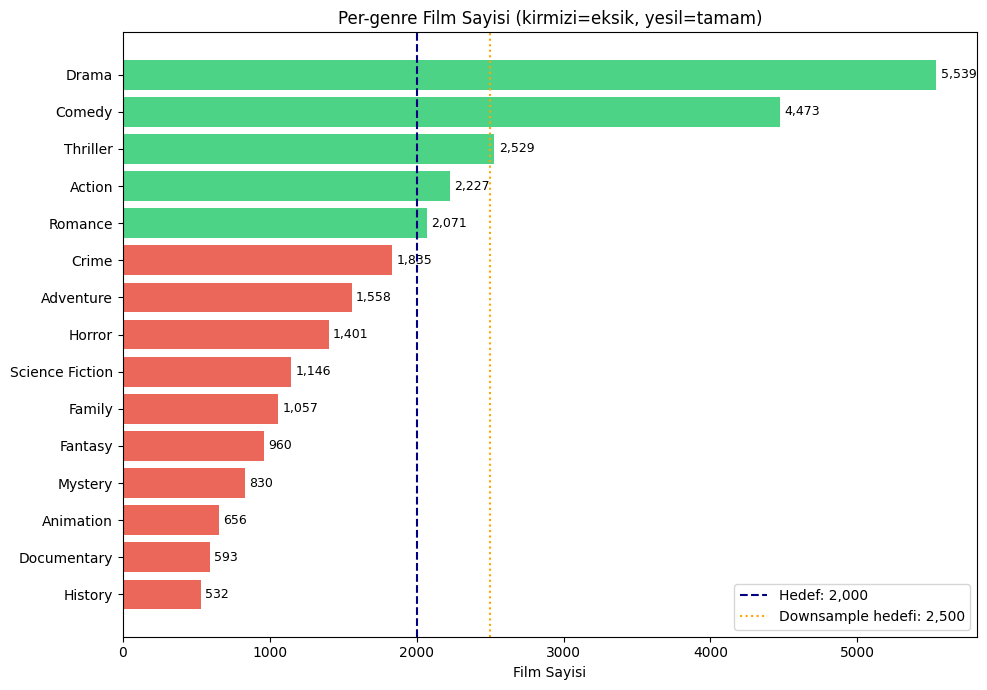

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if s == 'EKSIK' else '#2ecc71' for s in counts_df['status']]
bars = ax.barh(counts_df['genre'], counts_df['count'], color=colors, alpha=0.85)

ax.axvline(TARGET_PER_GENRE, color='navy', linestyle='--', linewidth=1.5,
           label=f'Hedef: {TARGET_PER_GENRE:,}')
ax.axvline(DOWNSAMPLE_TO, color='orange', linestyle=':', linewidth=1.5,
           label=f'Downsample hedefi: {DOWNSAMPLE_TO:,}')

for bar, count in zip(bars, counts_df['count']):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=9)

ax.set_xlabel('Film Sayisi')
ax.set_title('Per-genre Film Sayisi (kirmizi=eksik, yesil=tamam)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Tur Kombinasyonu Frekans Analizi

In [5]:
combo_counts = Counter(frozenset(gs) for gs in df['genres'])

combo_df = pd.DataFrame(
    [(' + '.join(sorted(combo)), len(combo), cnt)
     for combo, cnt in combo_counts.items()],
    columns=['combination', 'n_genres', 'count']
).sort_values('count', ascending=False).reset_index(drop=True)

print(f'Toplam unique kombinasyon : {len(combo_df)}')
print(f'Tek-tur film sayisi       : {combo_df[combo_df["n_genres"]==1]["count"].sum():,}')
print(f'Iki-tur film sayisi       : {combo_df[combo_df["n_genres"]==2]["count"].sum():,}')
print(f'Uc+ tur film sayisi       : {combo_df[combo_df["n_genres"]>=3]["count"].sum():,}')
print()
print('En sik 20 kombinasyon:')
print(combo_df.head(20).to_string(index=False))

Toplam unique kombinasyon : 708
Tek-tur film sayisi       : 3,225
Iki-tur film sayisi       : 4,092
Uc+ tur film sayisi       : 4,773

En sik 20 kombinasyon:
                         combination  n_genres  count
                               Drama         1   1163
                              Comedy         1   1032
                      Comedy + Drama         2    565
                     Drama + Romance         2    533
                         Documentary         1    463
            Comedy + Drama + Romance         3    458
                    Comedy + Romance         2    398
                     Drama + History         2    241
            Crime + Drama + Thriller         3    216
                       Crime + Drama         2    210
                              Horror         1    193
                    Drama + Thriller         2    189
                   Horror + Thriller         2    189
           Action + Crime + Thriller         3    148
                      Comedy + C

In [6]:
two_genre = combo_df[combo_df['n_genres'] == 2].copy()
two_genre['deficit'] = (TARGET_PER_COMBO - two_genre['count']).clip(lower=0)
two_genre_missing = two_genre[two_genre['deficit'] > 0].sort_values('deficit', ascending=False)

print(f'2-tur kombinasyonu toplam          : {len(two_genre)}')
print(f'Hedef altinda (< {TARGET_PER_COMBO} film)   : {len(two_genre_missing)}')
print()
print('Eksik 2-tur kombinasyonlari (ilk 20):')
print(two_genre_missing.head(20).to_string(index=False))

2-tur kombinasyonu toplam          : 80
Hedef altinda (< 50 film)   : 61

Eksik 2-tur kombinasyonlari (ilk 20):
                  combination  n_genres  count  deficit
              Family + Horror         2      1       49
    Fantasy + Science Fiction         2      1       49
    Mystery + Science Fiction         2      1       49
    Romance + Science Fiction         2      1       49
         Animation + Thriller         2      1       49
        Documentary + Mystery         2      1       49
        Documentary + Romance         2      1       49
           History + Thriller         2      1       49
          Animation + Fantasy         2      2       48
        Adventure + Animation         2      2       48
        Documentary + Fantasy         2      2       48
              Crime + Romance         2      3       47
            Adventure + Crime         2      3       47
      Crime + Science Fiction         2      3       47
Documentary + Science Fiction         2      3  

## 4. Co-occurrence Heatmap

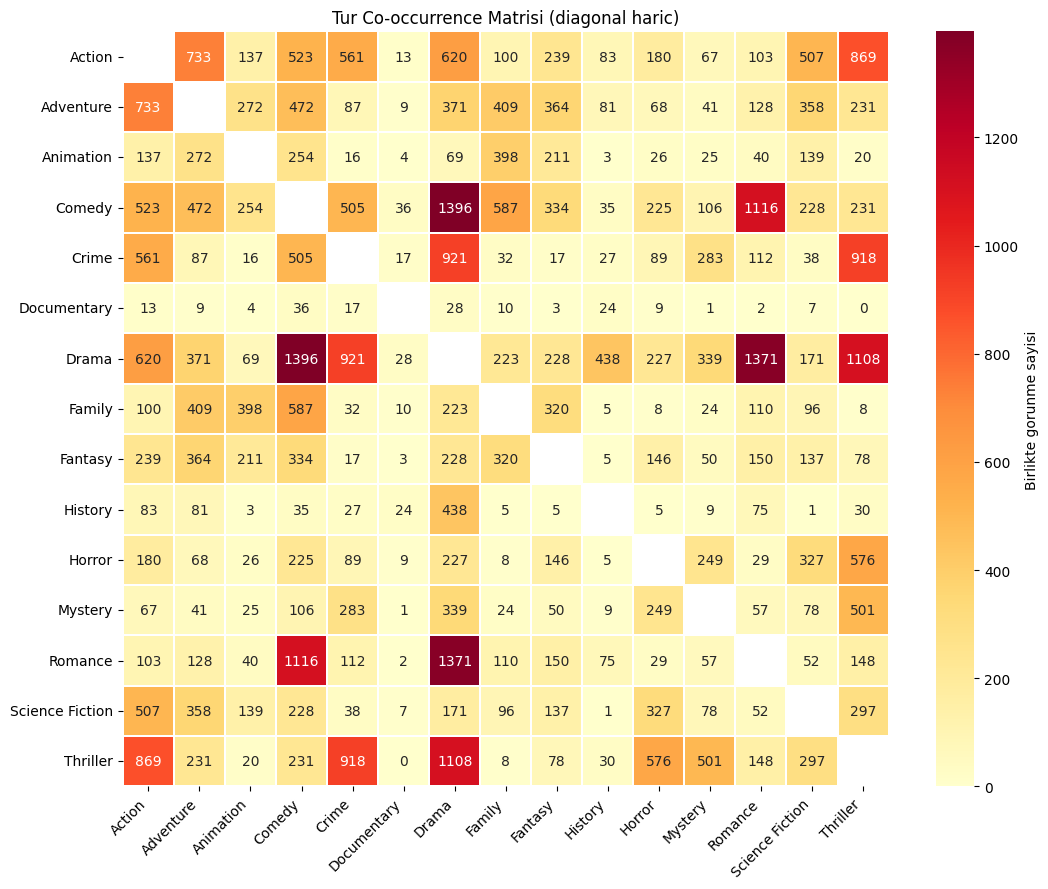


En sik birlikte gorunen 15 tur cifti:
genre_a         genre_b  cooc
 Comedy           Drama  1396
  Drama         Romance  1371
 Comedy         Romance  1116
  Drama        Thriller  1108
  Crime           Drama   921
  Crime        Thriller   918
 Action        Thriller   869
 Action       Adventure   733
 Action           Drama   620
 Comedy          Family   587
 Horror        Thriller   576
 Action           Crime   561
 Action          Comedy   523
 Action Science Fiction   507
 Comedy           Crime   505


In [7]:
n   = len(TARGET_GENRES)
g2i = {g: i for i, g in enumerate(TARGET_GENRES)}
cooc = np.zeros((n, n), dtype=int)

for genres in df['genres']:
    for g1 in genres:
        for g2 in genres:
            cooc[g2i[g1], g2i[g2]] += 1

cooc_df = pd.DataFrame(cooc, index=TARGET_GENRES, columns=TARGET_GENRES)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.eye(n, dtype=bool)
sns.heatmap(
    cooc_df, mask=mask, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Birlikte gorunme sayisi'}
)
ax.set_title('Tur Co-occurrence Matrisi (diagonal haric)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((TARGET_GENRES[i], TARGET_GENRES[j], cooc[i, j]))
pairs_df = pd.DataFrame(pairs, columns=['genre_a', 'genre_b', 'cooc']) \
    .sort_values('cooc', ascending=False).head(15)
print('\nEn sik birlikte gorunen 15 tur cifti:')
print(pairs_df.to_string(index=False))

## 5. gap_report.csv Uretimi

In [8]:
rows = []

# Tek-tur bosluklari
for g in TARGET_GENRES:
    current = genre_counts.get(g, 0)
    target  = DOWNSAMPLE_TO if g in ('Drama', 'Comedy') else TARGET_PER_GENRE
    deficit = max(0, target - current)
    rows.append({
        'combination': g,
        'n_genres': 1,
        'current_count': current,
        'target_count': target,
        'deficit': deficit,
        'type': 'single'
    })

# 2-tur kombinasyonu bosluklari
for _, row in two_genre.iterrows():
    rows.append({
        'combination': row['combination'],
        'n_genres': 2,
        'current_count': row['count'],
        'target_count': TARGET_PER_COMBO,
        'deficit': int(row['deficit']),
        'type': 'pair'
    })

gap_df = pd.DataFrame(rows).sort_values(
    ['type', 'deficit'], ascending=[True, False]
).reset_index(drop=True)

gap_df.to_csv(GAP_REPORT, index=False)
print(f'gap_report.csv yazildi -> {GAP_REPORT}')
print(f'Toplam satir: {len(gap_df)}')
print()
single_gaps = gap_df[(gap_df['type'] == 'single') & (gap_df['deficit'] > 0)] \
    .sort_values('deficit', ascending=False)
print('Tek-tur bosluklari (deficit > 0):')
print(single_gaps[['combination', 'current_count', 'target_count', 'deficit']].to_string(index=False))

gap_report.csv yazildi -> ..\gap_report.csv
Toplam satir: 95

Tek-tur bosluklari (deficit > 0):
    combination  current_count  target_count  deficit
        History            532          2000     1468
    Documentary            593          2000     1407
      Animation            656          2000     1344
        Mystery            830          2000     1170
        Fantasy            960          2000     1040
         Family           1057          2000      943
Science Fiction           1146          2000      854
         Horror           1401          2000      599
      Adventure           1558          2000      442
          Crime           1835          2000      165


## 6. Scraping Oncelik Listesi

In [9]:
priority = gap_df[gap_df['type'] == 'single'].sort_values('deficit', ascending=False)

print('=' * 55)
print('PHASE 7 SCRAPING ONCELIK LISTESI')
print('=' * 55)
total_needed = 0
for _, row in priority.iterrows():
    if row['deficit'] > 0:
        print(f'  {row["combination"]:20s} -> +{int(row["deficit"]):,} film gerekli')
        total_needed += row['deficit']
    else:
        action = 'downsample' if row['combination'] in ('Drama', 'Comedy') else 'tamam'
        print(f'  {row["combination"]:20s} -> {action}')
print('=' * 55)
print(f'Minimum scraping hedefi  : ~{total_needed:,} film')
print(f'Ourtusme payi (+%30)     : ~{int(total_needed * 1.3):,} film')
print(f'Onerilecek CLOSESPIDER   : {int(total_needed * 1.3):,}')

PHASE 7 SCRAPING ONCELIK LISTESI
  History              -> +1,468 film gerekli
  Documentary          -> +1,407 film gerekli
  Animation            -> +1,344 film gerekli
  Mystery              -> +1,170 film gerekli
  Fantasy              -> +1,040 film gerekli
  Family               -> +943 film gerekli
  Science Fiction      -> +854 film gerekli
  Horror               -> +599 film gerekli
  Adventure            -> +442 film gerekli
  Crime                -> +165 film gerekli
  Action               -> tamam
  Comedy               -> downsample
  Drama                -> downsample
  Romance              -> tamam
  Thriller             -> tamam
Minimum scraping hedefi  : ~9,432 film
Ourtusme payi (+%30)     : ~12,261 film
Onerilecek CLOSESPIDER   : 12,261
